# 06 — Evaluation: Continuity-aware ours

**역할**: 기존 evaluation protocol은 그대로 유지하고, 기존 checkpoint 3개(`vanilla` / `periodic` / `trajectory`)와 새 continuity checkpoint를 비교합니다.

중요: 여기서는 **새로 학습하지 않습니다.**  
`artifacts/checkpoints`에 이미 있는 checkpoint를 로드해서 동일한 MuJoCo Ant-v5 rollout protocol로 평가합니다.

**최종 평가 모델 (4개)**
- `vanilla` — Vanilla DP (`vanilla_dp_ckpt.pt`)
- `periodic` — Periodic Phase (`phase_periodic_ckpt.pt`)
- `trajectory` — Phase Trajectory (`phase_trajectory_ckpt.pt`)
- `trajectory_sync` — **Phase Trajectory + Continuity (ours)** (`phase_trajectory_continuity_ckpt.pt`)

즉, 기존 `trajectory_sync` / `Phase Trajectory + Sync (ours)` 자리를 새 continuity 모델로 대체합니다.  
따라서 기존 plotting/table 함수는 그대로 `trajectory_sync` key를 사용하지만, 실제 checkpoint와 condition은 continuity-aware 모델입니다.

**Continuity condition**

\[
[\cos \phi_t,\ \sin \phi_t,\ \cos(\phi_t-\phi_{t-1}),\ \sin(\phi_t-\phi_{t-1})]
\]

**산출물**
- `results/table1_indist_quality_continuity_ours.md`
- `results/table2_frequency_tracking_continuity_ours.md`
- `results/eval_results_continuity_ours.npz`
- `figures/continuity_ours/eval_figure*.png`

**예상 소요**: Colab T4 기준 약 60–80분


In [1]:
# Google Drive mount and project-root setup for Colab
from pathlib import Path
import os

PROJECT_CANDIDATES = [
    Path('/content/drive/MyDrive/phase_conditioned_diffusion_policy (1)'),
    Path('/content/drive/MyDrive/phase_conditioned_diffusion_policy'),
]

try:
    from google.colab import drive
except ImportError:
    print(f'Not running in Google Colab; keeping current working directory: {Path.cwd()}')
else:
    drive.mount('/content/drive')

    PROJECT_DIR = next((p for p in PROJECT_CANDIDATES if p.exists()), None)
    if PROJECT_DIR is None:
        tried = '\n'.join(str(p) for p in PROJECT_CANDIDATES)
        raise FileNotFoundError(f'Expected project directory not found. Tried:\n{tried}')

    os.chdir(PROJECT_DIR)

    # Must be set before importing pcdp.paths.
    os.environ['PCDP_ARTIFACT_ROOT'] = str(PROJECT_DIR / 'artifacts')

    print(f'Current working directory: {Path.cwd()}')
    print(f'PCDP_ARTIFACT_ROOT: {os.environ["PCDP_ARTIFACT_ROOT"]}')


Mounted at /content/drive
Current working directory: /content/drive/MyDrive/phase_conditioned_diffusion_policy (1)
PCDP_ARTIFACT_ROOT: /content/drive/MyDrive/phase_conditioned_diffusion_policy (1)/artifacts


In [2]:
# Colab dependency setup
import importlib.util
import subprocess
import sys
from pathlib import Path

if importlib.util.find_spec("google.colab") is None:
    print("Not running in Google Colab; skipping dependency installation and using the current environment.")
else:
    project_root = Path.cwd()
    requirements_path = project_root / "requirements.txt"
    install_command = [sys.executable, "-m", "pip", "install"]

    if requirements_path.exists():
        # requirements.txt pins the runtime stack; -e . installs this repo from pyproject.toml.
        install_command.extend(["-r", str(requirements_path), "-e", str(project_root)])
    else:
        # Fallback to pyproject.toml dependencies if requirements.txt is unavailable.
        install_command.extend(["-e", str(project_root)])

    subprocess.check_call(install_command)

    import gymnasium as gym
    import mujoco
    import minari
    import torch

    gym.make("Ant-v5").close()

    print(f"gymnasium={gym.__version__}")
    print(f"mujoco={mujoco.__version__}")
    print(f"minari={minari.__version__}")
    print(f"torch={torch.__version__}")
    print("Ant-v5 environment smoke check passed.")


gymnasium=1.3.0
mujoco=3.9.0
minari=0.5.3
torch=2.11.0+cu128
Ant-v5 environment smoke check passed.


## 1. Artifact paths


In [3]:
from pcdp.paths import ARTIFACT_ROOT, DATA_DIR, CHECKPOINTS_DIR, RESULTS_DIR, FIGURES_DIR, ensure_artifact_dirs
ensure_artifact_dirs()
print(f'✓ artifact root: {ARTIFACT_ROOT}')


✓ artifact root: /content/drive/MyDrive/phase_conditioned_diffusion_policy (1)/artifacts


## 2. Imports + Config


In [4]:
import gymnasium as gym
import torch
import numpy as np
import pandas as pd
from pathlib import Path

from pcdp.configs import set_global_seed, get_experiment_config
from pcdp.dataset import load_project_data, encode_phase_cossin
from pcdp.evaluation import (
    build_eval_results_payload,
    build_frequency_sweep_protocol,
    load_evaluation_state,
    write_frequency_tracking_table_markdown,
    write_table1_summary_markdown,
    save_eval_results_npz,
    LoadedEvalModel,
    ModelEvalSpec,
)
import pcdp.evaluation as ev

from pcdp.training import load_checkpoint
from pcdp.experiment_plots import plot_paper_figures

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {torch.__version__}, device={device}')
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


PyTorch 2.11.0+cu128, device=cuda
Tesla T4


## 3. 데이터 및 체크포인트 로드

In [5]:
data = load_project_data(DATA_DIR)
set_global_seed(data['seed'], deterministic=True)


42

In [7]:
# Load baseline checkpoints and replace the original "ours" slot with
# Phase Trajectory + Continuity (ours).
#
# Important:
# Register the continuity config BEFORE load_evaluation_state(...),
# because the loader scans checkpoints and calls get_experiment_config(...).

import torch
from dataclasses import replace

import pcdp.configs as cfg_mod
import pcdp.sampling as sampling_mod
import pcdp.evaluation as ev

from pcdp.configs import EXPERIMENT_CONFIGS
from pcdp.evaluation import ModelEvalSpec


# ---------------------------------------------------------------------
# 1. Runtime continuity encoding and sampling condition
# ---------------------------------------------------------------------

def encode_phase_continuity_runtime(phase: torch.Tensor, prev_phase: torch.Tensor) -> torch.Tensor:
    """
    phase: (B, T)
    prev_phase: (B,)
    return: (B, T, 4)

    [cos(phi_t), sin(phi_t), cos(phi_t - phi_{t-1}), sin(phi_t - phi_{t-1})]
    """
    phase_enc = torch.stack([torch.cos(phase), torch.sin(phase)], dim=-1)

    prev = torch.cat([prev_phase[:, None], phase[:, :-1]], dim=1)
    delta = phase - prev
    delta_enc = torch.stack([torch.cos(delta), torch.sin(delta)], dim=-1)

    return torch.cat([phase_enc, delta_enc], dim=-1)


def trajectory_phase_continuity_sample_cond_fn(
    obs_window: torch.Tensor,
    phase_chunk: torch.Tensor,
    device: str = "cuda",
):
    """
    Sampling-time continuity-aware phase conditioning.
    """
    obs_window = obs_window.to(device)
    phase_chunk = phase_chunk.to(device)

    global_cond = obs_window.flatten(start_dim=1)

    if phase_chunk.shape[1] >= 2:
        delta0 = phase_chunk[:, 1] - phase_chunk[:, 0]
    else:
        delta0 = torch.zeros_like(phase_chunk[:, 0])

    prev_phase = phase_chunk[:, 0] - delta0
    per_step_cond = encode_phase_continuity_runtime(phase_chunk, prev_phase)

    return global_cond, per_step_cond


# Make the function visible to pcdp.sampling.
sampling_mod.trajectory_phase_continuity_sample_cond_fn = trajectory_phase_continuity_sample_cond_fn


# ---------------------------------------------------------------------
# 2. Patch config resolver so it recognizes the new sampling function
# ---------------------------------------------------------------------

def resolve_sample_cond_fn_patched(self):
    from pcdp.sampling import (
        vanilla_sample_cond_fn,
        periodic_phase_sample_cond_fn,
        trajectory_phase_sample_cond_fn,
    )

    cond_fns = {
        "vanilla_sample_cond_fn": vanilla_sample_cond_fn,
        "periodic_phase_sample_cond_fn": periodic_phase_sample_cond_fn,
        "trajectory_phase_sample_cond_fn": trajectory_phase_sample_cond_fn,
        "trajectory_phase_continuity_sample_cond_fn": sampling_mod.trajectory_phase_continuity_sample_cond_fn,
    }
    return cond_fns[self.sample_cond_fn]


cfg_mod.ExperimentConfig.resolve_sample_cond_fn = resolve_sample_cond_fn_patched


# ---------------------------------------------------------------------
# 3. Register phase_trajectory_continuity config BEFORE loading state
# ---------------------------------------------------------------------

base_cfg = EXPERIMENT_CONFIGS["phase_trajectory"]

continuity_cfg = replace(
    base_cfg,
    name="phase_trajectory_continuity",
    display_name="Phase Trajectory + Continuity (ours)",
    train_cond_fn="trajectory_phase_continuity_cond_fn",
    sample_cond_fn="trajectory_phase_continuity_sample_cond_fn",
    model=replace(base_cfg.model, per_step_cond_dim=4),
    artifacts=replace(
        base_cfg.artifacts,
        checkpoint_name="phase_trajectory_continuity_ckpt.pt",
        loss_plot_name="phase_trajectory_continuity_loss.png",
    ),
    tags=("phase", "per-step-cond", "continuity", "ours"),
)

EXPERIMENT_CONFIGS["phase_trajectory_continuity"] = continuity_cfg

continuity_ckpt = CHECKPOINTS_DIR / "phase_trajectory_continuity_ckpt.pt"
if not continuity_ckpt.exists():
    raise FileNotFoundError(f"Continuity checkpoint not found: {continuity_ckpt}")

print("✓ Runtime continuity config registered")
print("Available configs:", list(EXPERIMENT_CONFIGS.keys()))
print("Continuity checkpoint:", continuity_ckpt)
print("per_step_cond_dim:", continuity_cfg.model.per_step_cond_dim)


# ---------------------------------------------------------------------
# 4. Now load evaluation state
# ---------------------------------------------------------------------

state = load_evaluation_state(
    data,
    device=device,
    checkpoints_dir=CHECKPOINTS_DIR,
)


# ---------------------------------------------------------------------
# 5. Replace original trajectory_sync ours slot with continuity model
# ---------------------------------------------------------------------

lm = state.loaded_models["phase_trajectory_continuity"]

state.model_specs["trajectory_sync"] = ModelEvalSpec(
    loaded_name="phase_trajectory_continuity",
    label="Phase Trajectory + Continuity (ours)",
    model=lm.model,
    ema=lm.ema,
    cond_fn=lm.cond_fn,
    uses_phase_trajectory=True,
)

# Keep original 4-model evaluation format.
ev.MODEL_KEYS = [
    "vanilla",
    "periodic",
    "trajectory",
    "trajectory_sync",
]

# Patch labels for repository summary/figure helpers if these dictionaries exist.
if hasattr(ev, "SUMMARY_MODEL_LABELS"):
    ev.SUMMARY_MODEL_LABELS["trajectory_sync"] = "Phase Trajectory + Continuity (ours)"

if hasattr(ev, "PHASE_CONDITION_LABELS"):
    ev.PHASE_CONDITION_LABELS["trajectory_sync"] = "full phase trajectory + continuity"


# ---------------------------------------------------------------------
# 6. Sanity check: per-step condition must be 4D
# ---------------------------------------------------------------------

_dummy_obs = torch.zeros(
    2,
    int(data["OBS_HORIZON"]),
    int(data["OBS_DIM"]),
)

_dummy_phase = torch.zeros(
    2,
    int(data["PRED_HORIZON"]),
)

_global_cond, _per_step_cond = trajectory_phase_continuity_sample_cond_fn(
    _dummy_obs,
    _dummy_phase,
    device=device,
)

assert _per_step_cond.shape[-1] == 4, _per_step_cond.shape

print("\n✓ Continuity checkpoint loaded and registered as the ours slot.")
print("Evaluation model keys:", list(state.model_specs.keys()))
print("MODEL_KEYS:", ev.MODEL_KEYS)
print("Ours label:", state.model_specs["trajectory_sync"].label)
print("Ours loaded_name:", state.model_specs["trajectory_sync"].loaded_name)
print("Ours checkpoint:", continuity_ckpt)
print("Continuity per-step condition shape:", tuple(_per_step_cond.shape))


✓ Runtime continuity config registered
Available configs: ['vanilla', 'periodic_phase', 'phase_trajectory', 'phase_trajectory_sync', 'phase_trajectory_continuity']
Continuity checkpoint: /content/drive/MyDrive/phase_conditioned_diffusion_policy (1)/artifacts/checkpoints/phase_trajectory_continuity_ckpt.pt
per_step_cond_dim: 4
✓ Loaded: /content/drive/MyDrive/phase_conditioned_diffusion_policy (1)/artifacts/checkpoints/vanilla_dp_ckpt.pt  [best EMA]
  Best val: (50, 0.1269859652966261)
✓ Loaded: /content/drive/MyDrive/phase_conditioned_diffusion_policy (1)/artifacts/checkpoints/phase_periodic_ckpt.pt  [best EMA]
  Best val: (50, 0.1270238170400262)
✓ Loaded: /content/drive/MyDrive/phase_conditioned_diffusion_policy (1)/artifacts/checkpoints/phase_trajectory_ckpt.pt  [best EMA]
  Best val: (50, 0.12196485605090857)
✓ Loaded: /content/drive/MyDrive/phase_conditioned_diffusion_policy (1)/artifacts/checkpoints/phase_trajectory_continuity_ckpt.pt  [best EMA]
  Best val: (60, 0.12224340718239

## 4. 평가 프로토콜 정의

In [8]:
DT = 0.05

# Final evaluation setting: same protocol as the proposal notebook.
MAX_STEPS = 1000
N_SEEDS_INDIST = 20
N_SEEDS_SWEEP = 10

# For a quick smoke test only, temporarily uncomment these three lines:
# MAX_STEPS = 200
# N_SEEDS_INDIST = 2
# N_SEEDS_SWEEP = 2

freq_protocol = build_frequency_sweep_protocol(data, n_in_dist=3, ood_iqr_scale=1.5)

print(f"In-dist freqs: {freq_protocol.in_freqs.round(3).tolist()}")
print(f"OOD freqs:     {freq_protocol.ood_freqs.round(3).tolist()}")
print(f"Sweep freqs:   {freq_protocol.sweep_freqs.round(3).tolist()}")
print(f"Zones:         {freq_protocol.zone_labels.tolist()}")


In-dist freqs: [1.9249999523162842, 2.049999952316284, 2.174999952316284]
OOD freqs:     [1.5499999523162842, 2.549999952316284]
Sweep freqs:   [1.5499999523162842, 1.9249999523162842, 2.049999952316284, 2.174999952316284, 2.549999952316284]
Zones:         ['OOD-low (q25-1.5IQR)', 'in-dist (q25)', 'in-dist (q50)', 'in-dist (q75)', 'OOD-high (q75+1.5IQR)']


## 5. Table 1 — In-distribution performance

In [9]:
env = gym.make('Ant-v5')

table1_results = ev.run_in_distribution_evaluation(
    state,
    env=env,
    data=data,
    device=device,
    n_seeds=N_SEEDS_INDIST,
    max_steps=MAX_STEPS,
    dt=DT,
)


=== Table 1: In-dist @ f=2.023 Hz, n=20 seeds ===


--- Vanilla DP ---
  seed 0: survival=1000 steps, total_reward=   588.0, reward/step= 0.588, x_vel= 0.015
  seed 1: survival=1000 steps, total_reward=   621.4, reward/step= 0.621, x_vel= 0.084
  seed 2: survival= 55 steps, total_reward=   128.4, reward/step= 2.335, x_vel= 1.975
  seed 3: survival=1000 steps, total_reward=   810.4, reward/step= 0.810, x_vel= 0.220
  seed 4: survival=1000 steps, total_reward=   698.1, reward/step= 0.698, x_vel= 0.124
  seed 5: survival=1000 steps, total_reward=   631.8, reward/step= 0.632, x_vel= 0.048
  seed 6: survival=1000 steps, total_reward=  1247.6, reward/step= 1.248, x_vel= 0.744
  seed 7: survival=1000 steps, total_reward=   723.6, reward/step= 0.724, x_vel= 0.138
  seed 8: survival= 83 steps, total_reward=   230.6, reward/step= 2.779, x_vel= 2.390
  seed 9: survival=1000 steps, total_reward=   623.5, reward/step= 0.623, x_vel= 0.039
  seed 10: survival=1000 steps, total_reward=   720.9, reward

In [10]:
ev.print_table1_summary(state, table1_results, freq_hz=float(data['freq_window_mean']))

write_table1_summary_markdown(
    state,
    table1_results,
    RESULTS_DIR / 'table1_indist_quality_continuity_ours.md',
    freq_hz=float(data['freq_window_mean']),
    interval='ci95',
)



=== Table 1: In-distribution @ f=2.023 Hz, n=20 ===
                               Model  Survival   Reward/step  Forward vel. Measured freq
                          Vanilla DP 862 ± 327 1.013 ± 0.642 0.477 ± 0.711 1.425 ± 0.208
                      Periodic Phase 907 ± 279 0.934 ± 0.353 0.411 ± 0.420 1.355 ± 0.183
                    Phase Trajectory 696 ± 313 1.467 ± 0.418 1.104 ± 0.351 1.904 ± 0.180
Phase Trajectory + Continuity (ours) 638 ± 357 1.327 ± 0.501 0.985 ± 0.419 1.886 ± 0.204
✓ /content/drive/MyDrive/phase_conditioned_diffusion_policy (1)/artifacts/results/table1_indist_quality_continuity_ours.md


PosixPath('/content/drive/MyDrive/phase_conditioned_diffusion_policy (1)/artifacts/results/table1_indist_quality_continuity_ours.md')

## 6. Table 2 — Frequency command tracking

In [11]:
# Uses the repository's original phase-model keys:
# periodic, trajectory, trajectory_sync.
# Here trajectory_sync has already been replaced with the continuity model.
freq_results = ev.run_frequency_sweep_evaluation(
    state,
    freq_protocol,
    env=env,
    data=data,
    device=device,
    n_seeds=N_SEEDS_SWEEP,
    max_steps=MAX_STEPS,
    dt=DT,
)


=== Periodic Phase frequency sweep ===

--- freq=1.550 Hz (OOD-low) ---
  seed 0: survival=1000 steps, total_reward=   750.5, reward/step= 0.750, x_vel= 0.187
  seed 1: survival=1000 steps, total_reward=   844.6, reward/step= 0.845, x_vel= 0.331
  seed 2: survival=1000 steps, total_reward=   671.5, reward/step= 0.671, x_vel= 0.057
  seed 3: survival=1000 steps, total_reward=   779.2, reward/step= 0.779, x_vel= 0.205
  seed 4: survival=1000 steps, total_reward=   734.0, reward/step= 0.734, x_vel= 0.158
  seed 5: survival=1000 steps, total_reward=   936.2, reward/step= 0.936, x_vel= 0.379
  seed 6: survival=1000 steps, total_reward=   867.6, reward/step= 0.868, x_vel= 0.337
  seed 7: survival=1000 steps, total_reward=   997.6, reward/step= 0.998, x_vel= 0.483
  seed 8: survival=1000 steps, total_reward=   990.5, reward/step= 0.990, x_vel= 0.432
  seed 9: survival=122 steps, total_reward=   127.0, reward/step= 1.041, x_vel= 0.597

Survival:  mean=912 ± 263 steps
Reward:    mean=769.8 ± 23

In [12]:
ev.print_frequency_sweep_summary(data, freq_protocol, freq_results)

write_frequency_tracking_table_markdown(
    freq_protocol,
    freq_results,
    RESULTS_DIR / 'table2_frequency_tracking_continuity_ours.md',
    interval='ci95',
)


=== Table 2: Frequency command tracking ===
freq_cmd                  zone                                model     freq_meas    |freq_err|           PLV   reward/step
   1.550  OOD-low (q25-1.5IQR)                       Periodic Phase 1.305 ± 0.101 0.245 ± 0.101 0.361 ± 0.112 0.861 ± 0.120
   1.550  OOD-low (q25-1.5IQR)                     Phase Trajectory 1.498 ± 0.037 0.052 ± 0.037 0.887 ± 0.019 0.982 ± 0.086
   1.550  OOD-low (q25-1.5IQR) Phase Trajectory + Continuity (ours) 1.498 ± 0.036 0.052 ± 0.036 0.883 ± 0.034 0.891 ± 0.136
   1.925         in-dist (q25)                       Periodic Phase 1.329 ± 0.158 0.596 ± 0.158 0.306 ± 0.082 0.895 ± 0.181
   1.925         in-dist (q25)                     Phase Trajectory 1.867 ± 0.114 0.059 ± 0.114 0.875 ± 0.155 1.633 ± 0.320
   1.925         in-dist (q25) Phase Trajectory + Continuity (ours) 1.912 ± 0.022 0.014 ± 0.022 0.935 ± 0.024 1.666 ± 0.377
   2.050         in-dist (q50)                       Periodic Phase 1.335 ± 0.225 0.715 

PosixPath('/content/drive/MyDrive/phase_conditioned_diffusion_policy (1)/artifacts/results/table2_frequency_tracking_continuity_ours.md')

## 7. Figures — Contribution-focused visualizations

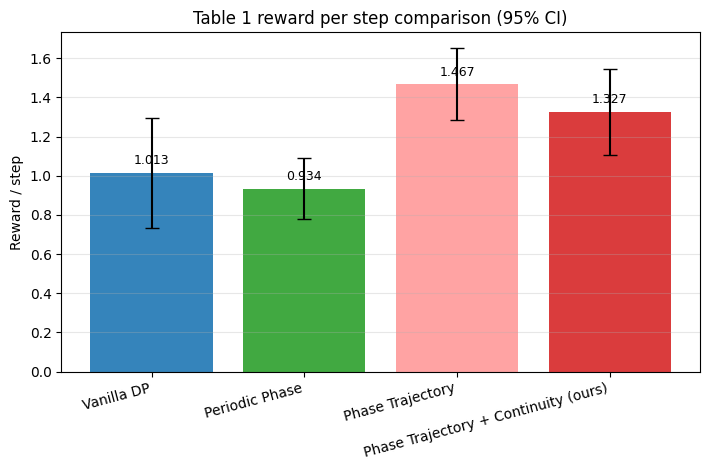

✓ /content/drive/MyDrive/phase_conditioned_diffusion_policy (1)/artifacts/figures/continuity_ours/eval_figure1_reward_per_step_comparison.png


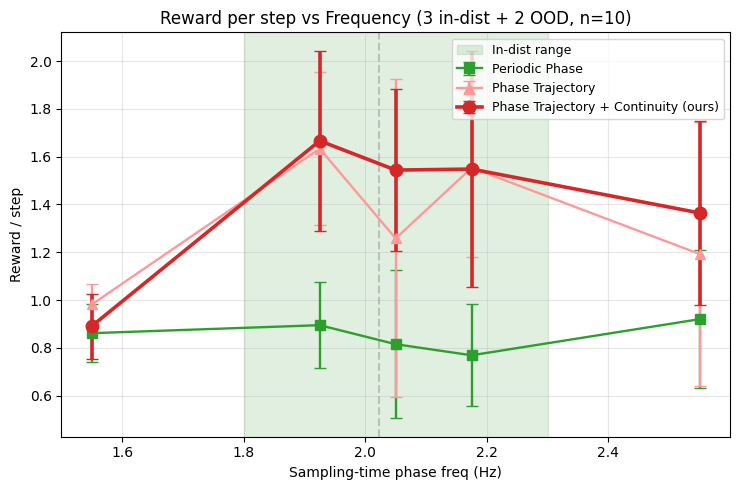

✓ /content/drive/MyDrive/phase_conditioned_diffusion_policy (1)/artifacts/figures/continuity_ours/eval_figure2_reward_per_step_vs_freq.png


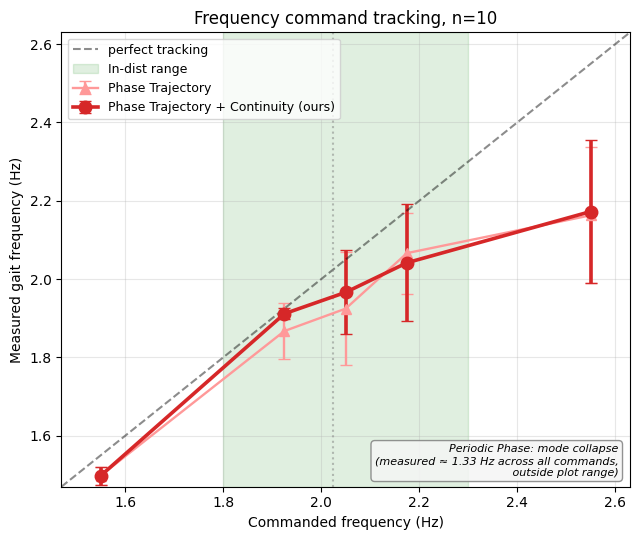

✓ /content/drive/MyDrive/phase_conditioned_diffusion_policy (1)/artifacts/figures/continuity_ours/eval_figure3_target_vs_measured_freq.png


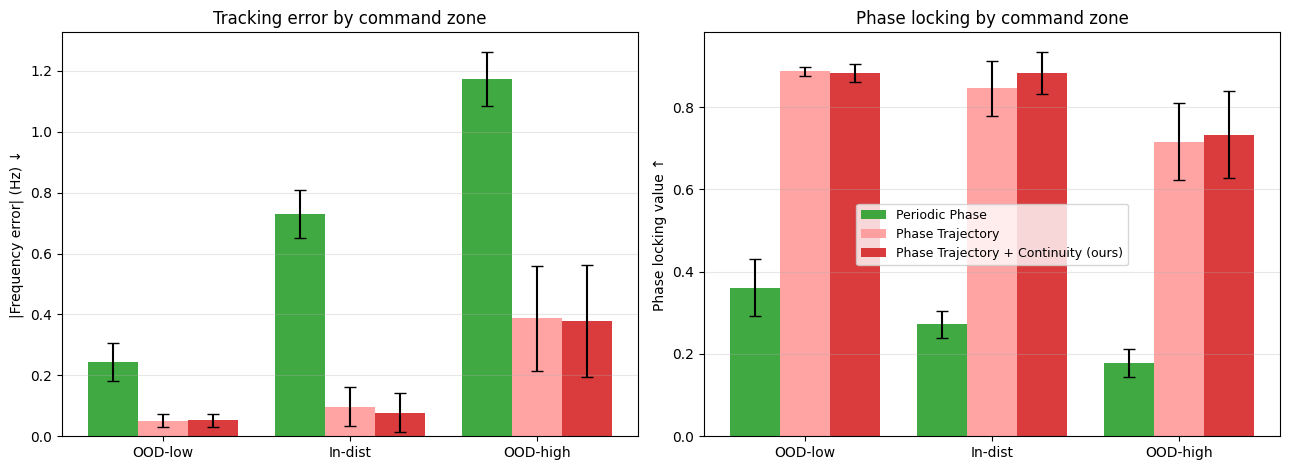

✓ /content/drive/MyDrive/phase_conditioned_diffusion_policy (1)/artifacts/figures/continuity_ours/eval_figure4_zone_tracking_metrics.png


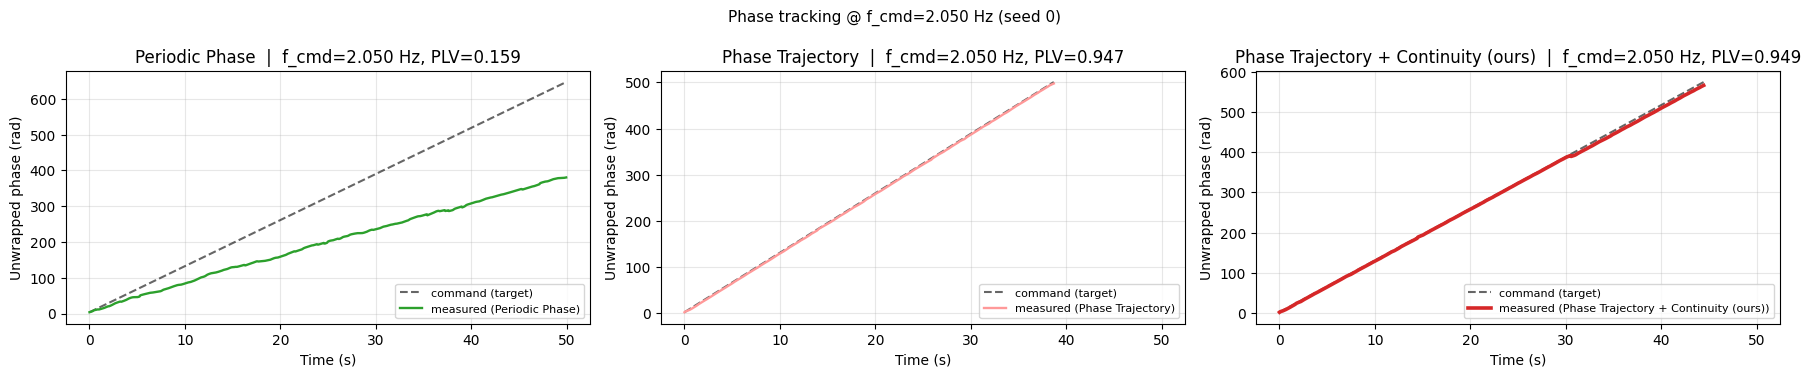

✓ /content/drive/MyDrive/phase_conditioned_diffusion_policy (1)/artifacts/figures/continuity_ours/eval_figure5_phase_tracking_timeseries.png
✓ Figures saved to: /content/drive/MyDrive/phase_conditioned_diffusion_policy (1)/artifacts/figures/continuity_ours


In [13]:
continuity_figures_dir = FIGURES_DIR / 'continuity_ours'

plot_paper_figures(
    table1_results,
    freq_results,
    freq_protocol,
    data,
    continuity_figures_dir,
    n_seeds_sweep=N_SEEDS_SWEEP,
    state=state,
    interval='ci95',
)

print(f'✓ Figures saved to: {continuity_figures_dir}')


## 8. 결과 저장 — `eval_results.npz`

In [14]:
eval_payload = build_eval_results_payload(
    data,
    table1_results,
    freq_protocol,
    freq_results,
    n_seeds_indist=N_SEEDS_INDIST,
    n_seeds_sweep=N_SEEDS_SWEEP,
)

save_eval_results_npz(
    eval_payload,
    RESULTS_DIR / 'eval_results_continuity_ours.npz'
)


✓ Saved: /content/drive/MyDrive/phase_conditioned_diffusion_policy (1)/artifacts/results/eval_results_continuity_ours.npz (43.8 KB)

Keys: ['n_seeds_indist', 'n_seeds_sweep', 'f_mean', 'freq_window_min', 'freq_window_max', 'in_freqs', 'ood_freqs', 'sweep_freqs', 'sweep_zone_labels', 'table1_vanilla_survival', 'table1_vanilla_reward', 'table1_vanilla_reward_per_step', 'table1_vanilla_mean_x_velocity', 'table1_vanilla_x_displacement', 'table1_vanilla_mean_reward_forward', 'table1_vanilla_measured_freq_hz', 'table1_vanilla_freq_error_hz', 'table1_vanilla_abs_freq_error_hz', 'table1_vanilla_freq_ratio', 'table1_vanilla_mean_abs_phase_error', 'table1_vanilla_phase_locking_value', 'table1_vanilla_phase_offset_error', 'table1_vanilla_abs_phase_offset_error', 'table1_periodic_survival', 'table1_periodic_reward', 'table1_periodic_reward_per_step', 'table1_periodic_mean_x_velocity', 'table1_periodic_x_displacement', 'table1_periodic_mean_reward_forward', 'table1_periodic_measured_freq_hz', 'tabl

PosixPath('/content/drive/MyDrive/phase_conditioned_diffusion_policy (1)/artifacts/results/eval_results_continuity_ours.npz')